# Notebook 02: Survival Analysis & LTV Modeling

**Objective:** Build and evaluate the core pLTV (predicted Lifetime Value) framework using:
1. **Cox Proportional Hazards** for time-to-churn prediction (survival probabilities)
2. **Gradient Boosting Survival Analysis** for model comparison (interpretability vs. performance)
3. **LightGBM Regressor** for 180-day revenue prediction
4. **Combined pLTV** = P(survive 180 days | Cox) x E(revenue | LightGBM)

**Business Context:** The mobile gaming UA team needs to predict which players will retain and how much they will spend, so they can optimise GBP 2M in annual ad spend across acquisition channels. The pLTV framework enables precision targeting: invest more in high-value acquisition channels, less in those that attract churners.

**Sections:**
1. Setup & Data Loading
2. Feature Preparation & Selection
3. Kaplan-Meier Exploration
4. Cox Proportional Hazards Model
5. Proportional Hazards Assumption Validation
6. Cox vs. LightGBM Survival Comparison
7. LTV Revenue Modeling (LightGBM with Optuna)
8. Combined pLTV Framework
9. Business Validation & Model Summary

---
## 1. Setup & Data Loading

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

# Project imports
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling import (
    FeatureSelector,
    LTVPredictor,
    PLTVCalculator,
    SurvivalAnalyzer,
    save_model,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Visualisation settings from config
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

viz_cfg = config["visualization"]
sns.set_theme(style=viz_cfg["style"], font_scale=1.1)
plt.rcParams["figure.dpi"] = viz_cfg["figure_dpi"]
plt.rcParams["font.size"] = viz_cfg["font_size"]
PALETTE = viz_cfg["palette"]
FIG_DIR = PROJECT_ROOT / config["outputs"]["figures_dir"]
MODEL_DIR = PROJECT_ROOT / config["outputs"]["models_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = config["project"]["random_seed"]
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Random seed: {SEED}")

Project root: c:\Users\matt_\Documents\Projects\Data Science\career-development\portfolio-projects\player_ltv_survival_analysis
Random seed: 42


In [2]:
# Load processed splits
processed_dir = PROJECT_ROOT / config["data"]["processed_dir"]
train_df = pd.read_csv(processed_dir / "train.csv")
val_df = pd.read_csv(processed_dir / "validation.csv")
test_df = pd.read_csv(processed_dir / "test.csv")

print(f"Train: {train_df.shape} | Churn rate: {train_df['event_observed'].mean():.1%}")
print(f"Val:   {val_df.shape}  | Churn rate: {val_df['event_observed'].mean():.1%}")
print(f"Test:  {test_df.shape} | Churn rate: {test_df['event_observed'].mean():.1%}")
print(f"\nTarget columns: duration_days, event_observed, total_revenue_180d")
print(f"Train revenue: mean=GBP {train_df['total_revenue_180d'].mean():.0f}, "
      f"median=GBP {train_df['total_revenue_180d'].median():.0f}")

Train: (348, 40) | Churn rate: 24.1%
Val:   (47, 40)  | Churn rate: 10.6%
Test:  (105, 40) | Churn rate: 20.0%

Target columns: duration_days, event_observed, total_revenue_180d
Train revenue: mean=GBP 1056, median=GBP 745


---
## 2. Feature Preparation & Selection

Before fitting models, we prepare features using the pipeline defined in `src/modeling.py`:
1. One-hot encode categoricals (plan_tier, referral_source)
2. StandardScaler for all numeric features
3. Feature selection: correlation filtering (r > 0.85), VIF > 5 removal, RFE with Cox (top 20)

The target is 15-20 features that balance prediction power with interpretability.

In [3]:
# Initialize SurvivalAnalyzer and prepare features
sa = SurvivalAnalyzer(config)
X_train_all, y_train = sa._prepare_features(train_df, fit_scaler=True)
X_val_all, y_val = sa._prepare_features(val_df)
X_test_all, y_test = sa._prepare_features(test_df)

print(f"Feature matrix shape (before selection): {X_train_all.shape}")
print(f"Features: {list(X_train_all.columns)}")

Feature matrix shape (before selection): (348, 33)
Features: ['avg_satisfaction_score', 'avg_session_duration_7d', 'beta_feature_adoption_flag', 'billing_frequency_annual_flag', 'days_since_last_session', 'days_since_signup', 'days_to_first_purchase', 'error_rate', 'fast_resolution_rate', 'feature_diversity_score', 'has_downgraded_flag', 'has_upgraded_flag', 'has_urgent_ticket_flag', 'provided_feedback', 'revenue_trend_slope_60d', 'satisfaction_missing', 'seats', 'signup_day_of_week', 'signup_month', 'subscription_churn_count', 'subscription_tenure_days', 'support_ticket_count_30d', 'total_revenue_30d', 'total_sessions_7d', 'usage_consistency_cv', 'usage_trend_slope_30d', 'weekend_usage_ratio', 'plan_tier_Enterprise', 'plan_tier_Pro', 'referral_source_event', 'referral_source_organic', 'referral_source_other', 'referral_source_partner']


In [4]:
# Run feature selection pipeline
selected_features = sa.select_features(X_train_all, y_train)

print(f"\nSelected {len(selected_features)} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

if sa.feature_selector and sa.feature_selector.selection_report_:
    report = sa.feature_selector.selection_report_
    if "correlation_filter" in report:
        print(f"\nCorrelation filter dropped: {report['correlation_filter'].get('dropped', [])}")
    if "vif_filter" in report:
        print(f"VIF filter dropped: {[d[0] for d in report['vif_filter'].get('dropped', [])]}")


Selected 20 features:
   1. billing_frequency_annual_flag
   2. days_since_last_session
   3. days_to_first_purchase
   4. error_rate
   5. fast_resolution_rate
   6. feature_diversity_score
   7. has_upgraded_flag
   8. has_urgent_ticket_flag
   9. provided_feedback
  10. revenue_trend_slope_60d
  11. signup_day_of_week
  12. subscription_tenure_days
  13. support_ticket_count_30d
  14. total_sessions_7d
  15. usage_consistency_cv
  16. usage_trend_slope_30d
  17. weekend_usage_ratio
  18. referral_source_event
  19. referral_source_organic
  20. referral_source_other

Correlation filter dropped: ['days_since_signup']
VIF filter dropped: []


---
## 3. Kaplan-Meier Exploration

Before parametric modeling, we examine non-parametric survival curves to understand retention patterns across key segments. This serves two purposes:
- Validate that the data has meaningful survival signal
- Preview whether segments have different baseline hazards (relevant for stratified Cox)

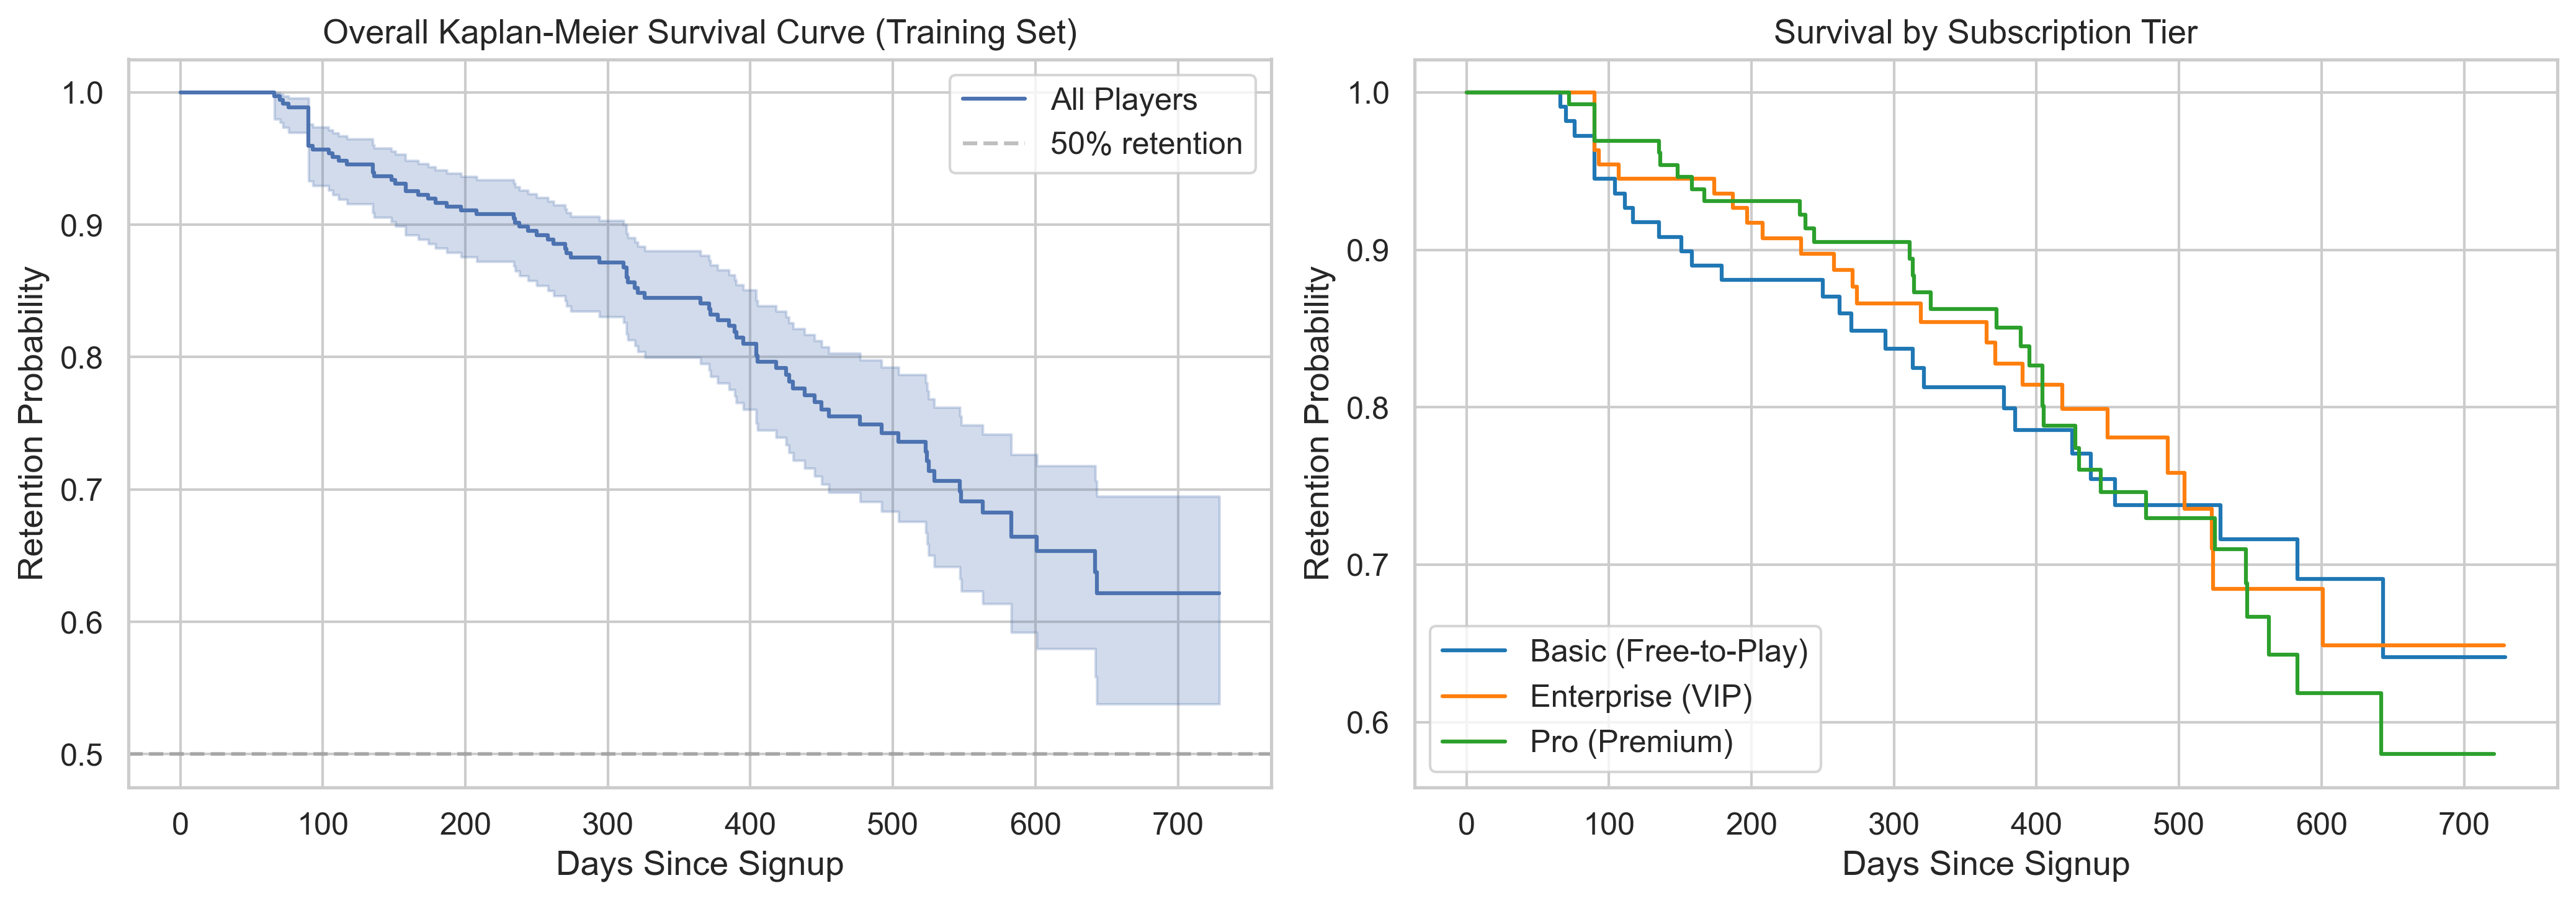


Log-rank test (Basic vs Enterprise): p=0.8029
Not significant at alpha=0.05


In [5]:
# Kaplan-Meier survival curves by plan tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall KM curve
kmf = KaplanMeierFitter()
kmf.fit(
    durations=train_df["duration_days"],
    event_observed=train_df["event_observed"],
    label="All Players",
)
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_title("Overall Kaplan-Meier Survival Curve (Training Set)", fontsize=13)
axes[0].set_xlabel("Days Since Signup")
axes[0].set_ylabel("Retention Probability")
axes[0].axhline(y=0.5, color="grey", linestyle="--", alpha=0.5, label="50% retention")
axes[0].legend()

# By plan tier
tier_map = config["terminology"]["plan_tier_mapping"]
colors = sns.color_palette(PALETTE, n_colors=3)
for i, tier in enumerate(train_df["plan_tier"].unique()):
    mask = train_df["plan_tier"] == tier
    kmf_tier = KaplanMeierFitter()
    kmf_tier.fit(
        durations=train_df.loc[mask, "duration_days"],
        event_observed=train_df.loc[mask, "event_observed"],
        label=f"{tier} ({tier_map.get(tier, tier)})",
    )
    kmf_tier.plot_survival_function(ax=axes[1], ci_show=False, color=colors[i])

axes[1].set_title("Survival by Subscription Tier", fontsize=13)
axes[1].set_xlabel("Days Since Signup")
axes[1].set_ylabel("Retention Probability")
axes[1].legend(loc="lower left")

plt.tight_layout()
fig.savefig(FIG_DIR / "km_survival_modeling.png", dpi=300, bbox_inches="tight")
plt.show()

# Log-rank test between tiers
tiers = train_df["plan_tier"].unique()
if len(tiers) >= 2:
    t1_mask = train_df["plan_tier"] == tiers[0]
    t2_mask = train_df["plan_tier"] == tiers[1]
    lr = logrank_test(
        train_df.loc[t1_mask, "duration_days"],
        train_df.loc[t2_mask, "duration_days"],
        event_observed_A=train_df.loc[t1_mask, "event_observed"],
        event_observed_B=train_df.loc[t2_mask, "event_observed"],
    )
    print(f"\nLog-rank test ({tiers[0]} vs {tiers[1]}): p={lr.p_value:.4f}")
    print("Significant" if lr.p_value < 0.05 else "Not significant", "at alpha=0.05")

---
## 4. Cox Proportional Hazards Model

The Cox PH model is our primary survival model. It estimates the hazard function:

$$h(t|X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_k X_k)$$

**Key outputs:**
- **Hazard ratios (HR):** HR > 1 means higher churn risk. E.g., HR = 1.8 for downgrade flag means 80% higher churn risk.
- **Survival function S(t):** Probability of retaining beyond time t.
- **Concordance index:** Model's ability to correctly rank players by risk (target > 0.75).

In [6]:
# Fit Cox PH model
cox_model = sa.fit_cox(X_train_all, y_train, feature_names=selected_features)

# Evaluate on all splits
cox_train_metrics = sa.evaluate_model(cox_model, X_train_all, y_train, "Cox (train)")
cox_val_metrics = sa.evaluate_model(cox_model, X_val_all, y_val, "Cox (val)")
cox_test_metrics = sa.evaluate_model(cox_model, X_test_all, y_test, "Cox (test)")

target_c = config["evaluation"]["survival_metrics"]["concordance_index"]["target"]
target_ibs = config["evaluation"]["survival_metrics"]["integrated_brier_score"]["target"]

print(f"\n{'Metric':<20} {'Train':<12} {'Validation':<12} {'Test':<12} {'Target':<12}")
print("-" * 68)
print(f"{'C-index':<20} {cox_train_metrics['c_index']:<12.4f} {cox_val_metrics['c_index']:<12.4f} {cox_test_metrics['c_index']:<12.4f} {'>'+str(target_c):<12}")
print(f"{'IBS':<20} {cox_train_metrics['ibs']:<12.4f} {cox_val_metrics['ibs']:<12.4f} {cox_test_metrics['ibs']:<12.4f} {'<'+str(target_ibs):<12}")


Metric               Train        Validation   Test         Target      
--------------------------------------------------------------------
C-index              0.7616       0.5048       0.3976       >0.75       
IBS                  0.0931       0.0710       0.0823       <0.15       


In [7]:
# Hazard ratios -- the key interpretable output
hr_df = sa.get_hazard_ratios()

print("\nHazard Ratios (sorted by magnitude):")
print("="*80)
for _, row in hr_df.iterrows():
    direction = "^" if row["hazard_ratio"] > 1 else "v"
    print(f"  {direction} {row['feature']:<35} HR={row['hazard_ratio']:.4f}  ({row['interpretation']})")

hr_df


Hazard Ratios (sorted by magnitude):
  ^ billing_frequency_annual_flag       HR=1.7074  (70.7% higher churn risk per unit increase)
  ^ total_sessions_7d                   HR=1.2699  (27.0% higher churn risk per unit increase)
  ^ usage_consistency_cv                HR=1.2621  (26.2% higher churn risk per unit increase)
  ^ support_ticket_count_30d            HR=1.2201  (22.0% higher churn risk per unit increase)
  ^ referral_source_other               HR=1.2041  (20.4% higher churn risk per unit increase)
  ^ referral_source_event               HR=1.2036  (20.4% higher churn risk per unit increase)
  ^ fast_resolution_rate                HR=1.1945  (19.4% higher churn risk per unit increase)
  v signup_day_of_week                  HR=0.9103  (9.0% lower churn risk per unit increase)
  v referral_source_organic             HR=0.8894  (11.1% lower churn risk per unit increase)
  v provided_feedback                   HR=0.8734  (12.7% lower churn risk per unit increase)
  v feature_dive

,feature,coefficient,hazard_ratio,interpretation
0,billing_frequency_annual_flag,0.534964,1.707387,70.7% higher churn risk per unit increase
1,total_sessions_7d,0.238974,1.269946,27.0% higher churn risk per unit increase
2,usage_consistency_cv,0.232803,1.262133,26.2% higher churn risk per unit increase
3,support_ticket_count_30d,0.198964,1.220137,22.0% higher churn risk per unit increase
4,referral_source_other,0.185704,1.204066,20.4% higher churn risk per unit increase
5,referral_source_event,0.185330,1.203616,20.4% higher churn risk per unit increase
6,fast_resolution_rate,0.177700,1.194467,19.4% higher churn risk per unit increase
7,signup_day_of_week,-0.093955,0.910324,9.0% lower churn risk per unit increase
8,referral_source_organic,-0.117240,0.889371,11.1% lower churn risk per unit increase
9,provided_feedback,-0.135379,0.873385,12.7% lower churn risk per unit increase


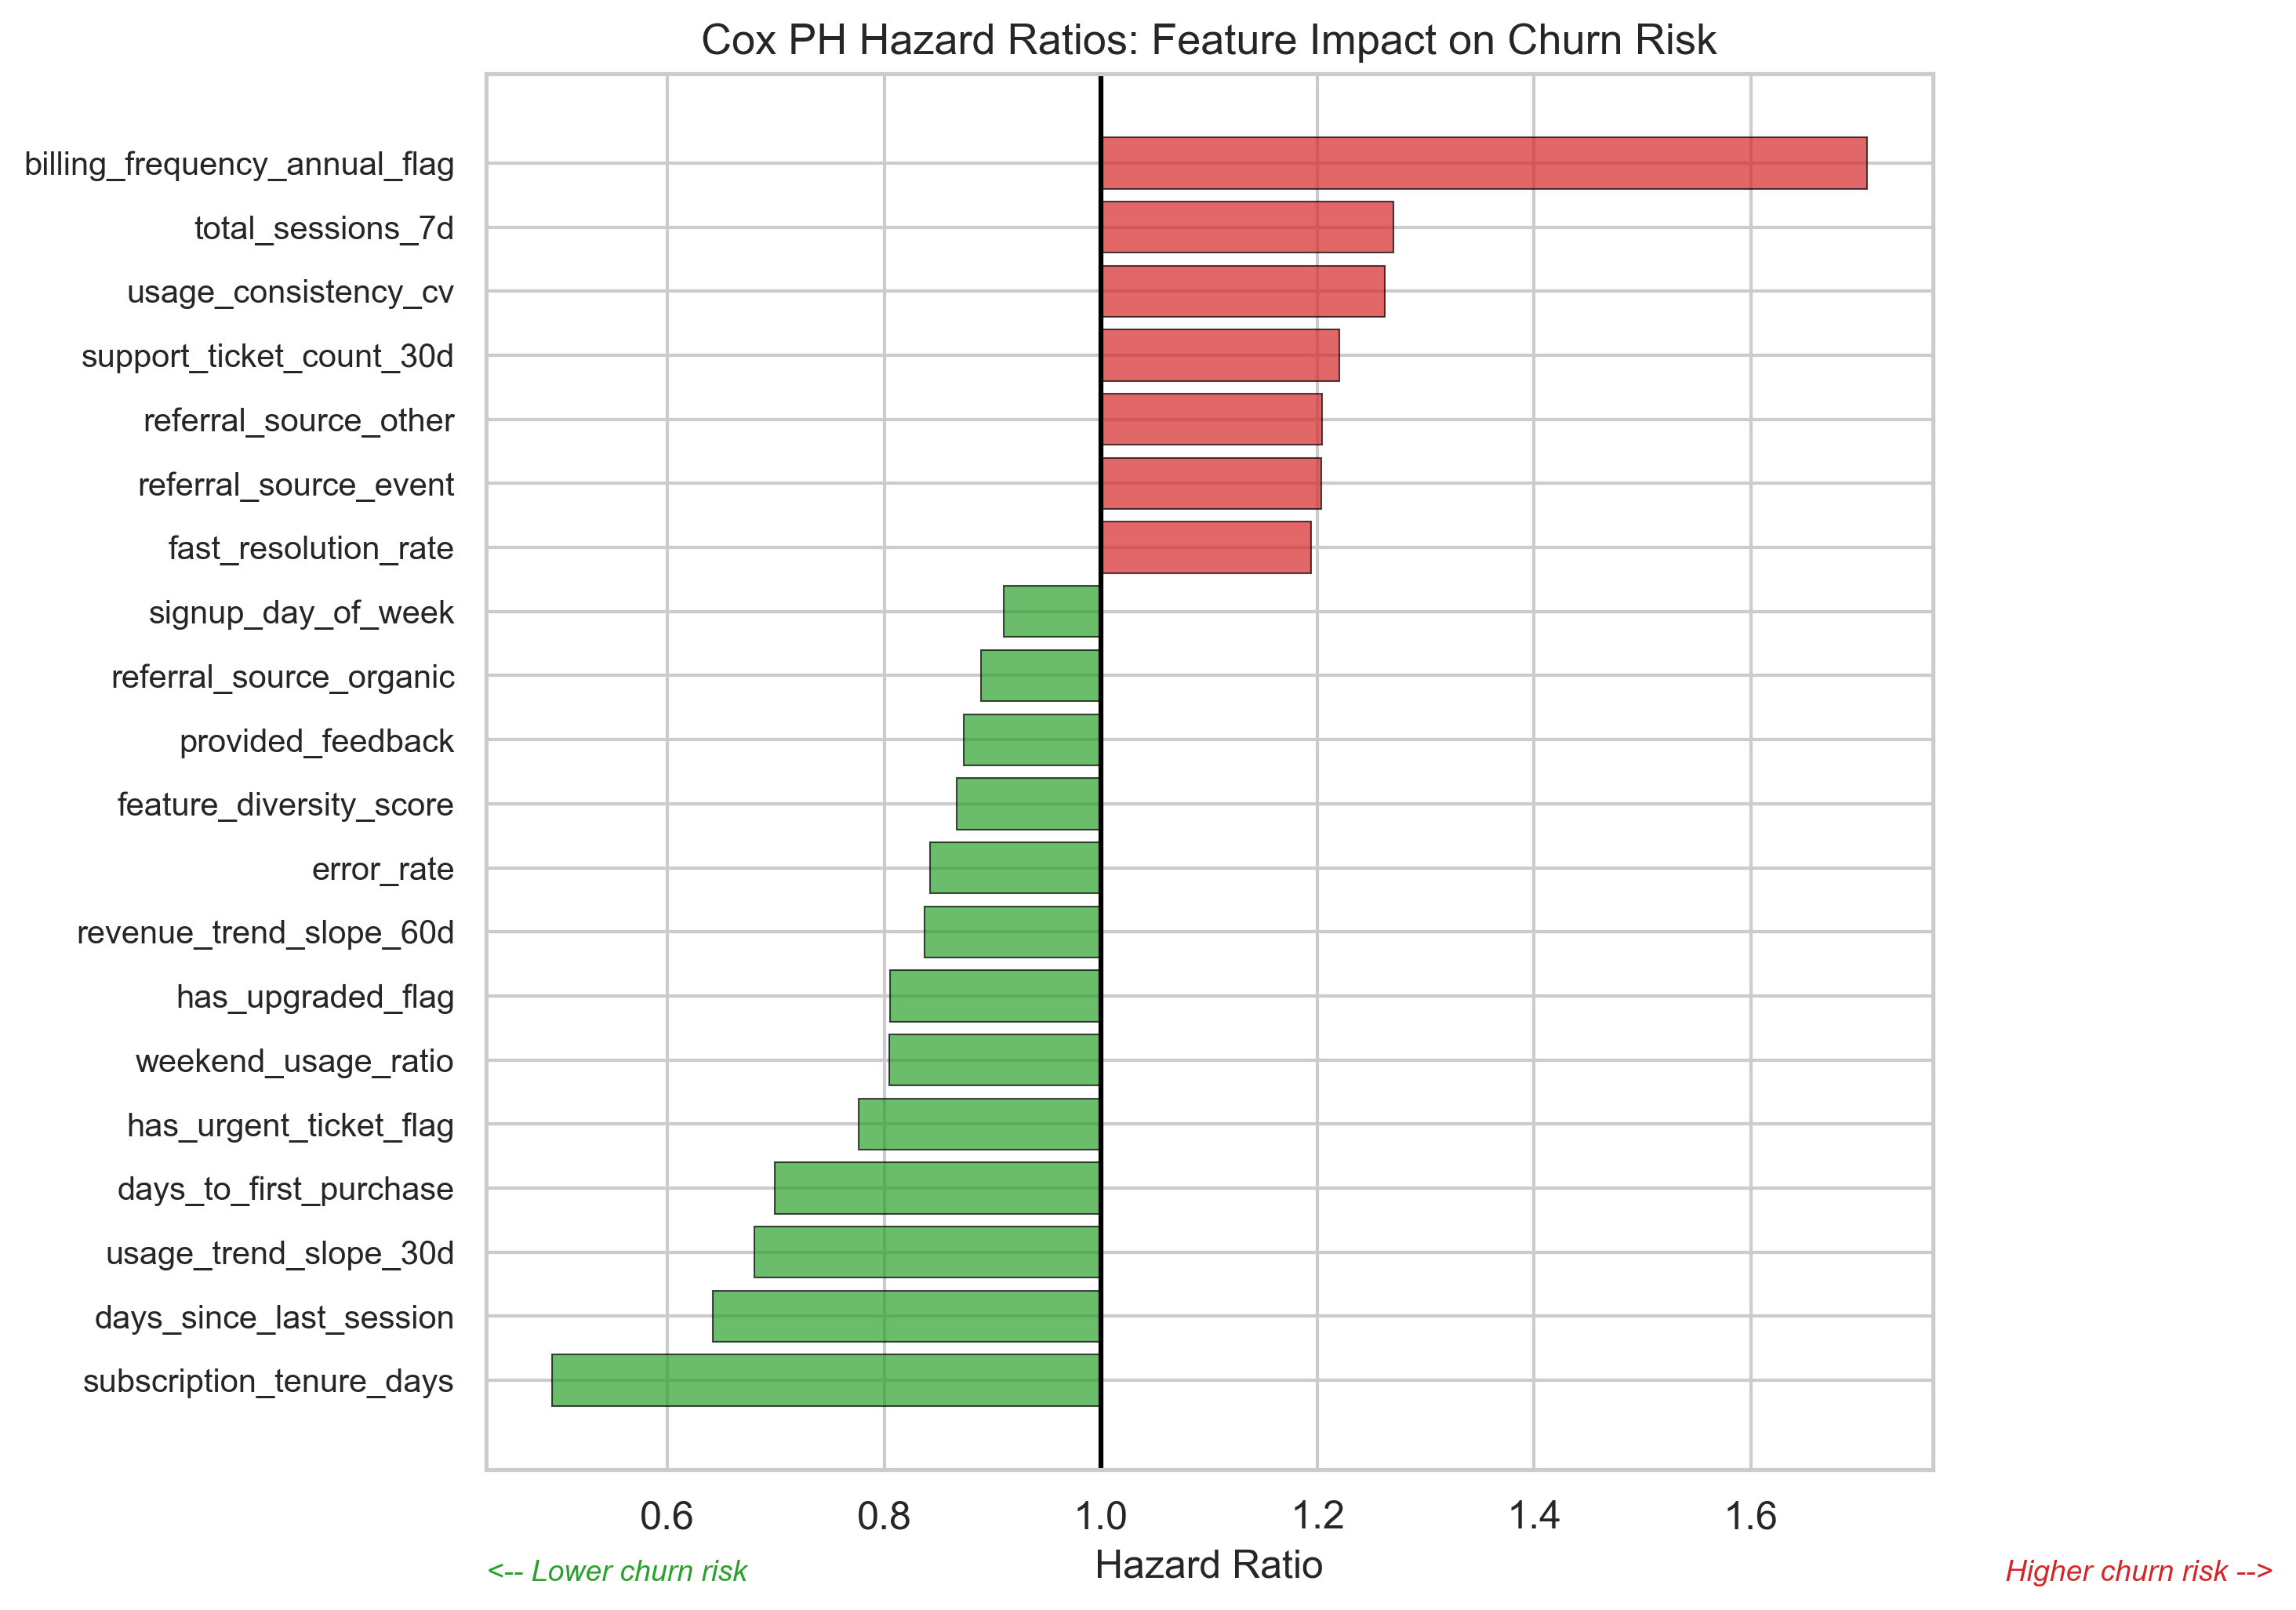

In [8]:
# Hazard ratio forest plot
fig, ax = plt.subplots(figsize=(10, max(6, len(hr_df) * 0.35)))

hr_sorted = hr_df.sort_values("hazard_ratio")
colors_hr = ["#d62728" if hr > 1 else "#2ca02c" for hr in hr_sorted["hazard_ratio"]]

ax.barh(
    range(len(hr_sorted)),
    hr_sorted["hazard_ratio"] - 1,
    left=1,
    color=colors_hr,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
)
ax.set_yticks(range(len(hr_sorted)))
ax.set_yticklabels(hr_sorted["feature"], fontsize=10)
ax.axvline(x=1, color="black", linewidth=1.5, linestyle="-")
ax.set_xlabel("Hazard Ratio", fontsize=12)
ax.set_title("Cox PH Hazard Ratios: Feature Impact on Churn Risk", fontsize=13)
ax.annotate("Higher churn risk -->", xy=(1.05, -0.08), xycoords="axes fraction",
            fontsize=9, color="#d62728", style="italic")
ax.annotate("<-- Lower churn risk", xy=(0.0, -0.08), xycoords="axes fraction",
            fontsize=9, color="#2ca02c", style="italic")

plt.tight_layout()
fig.savefig(FIG_DIR / "hazard_ratio_forest_plot.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 5. Proportional Hazards Assumption Validation

The Cox model assumes that hazard ratios are constant over time (proportional hazards). If this assumption is violated, the model's coefficients may be misleading. We test with:
1. **Schoenfeld residuals test:** p > 0.05 for each covariate means assumption holds
2. **Log-log survival plots:** Parallel lines indicate proportional hazards

In [9]:
# Test proportional hazards assumption using lifelines
ph_result = sa.validate_proportional_hazards(X_train_all, y_train)

print(f"PH Assumption Test Result: {'PASSED' if ph_result['assumption_holds'] else 'VIOLATED'}")
print(f"Alpha: {ph_result['alpha']}")
print(f"Recommendation: {ph_result['recommendation']}")

if ph_result.get("violations"):
    print(f"\nViolations detected:")
    for v in ph_result["violations"]:
        print(f"  - {v}")

Proportional hazard assumption looks okay.
PH Assumption Test Result: PASSED
Alpha: 0.05
Recommendation: Proportional hazards assumption holds. Cox model is appropriate.


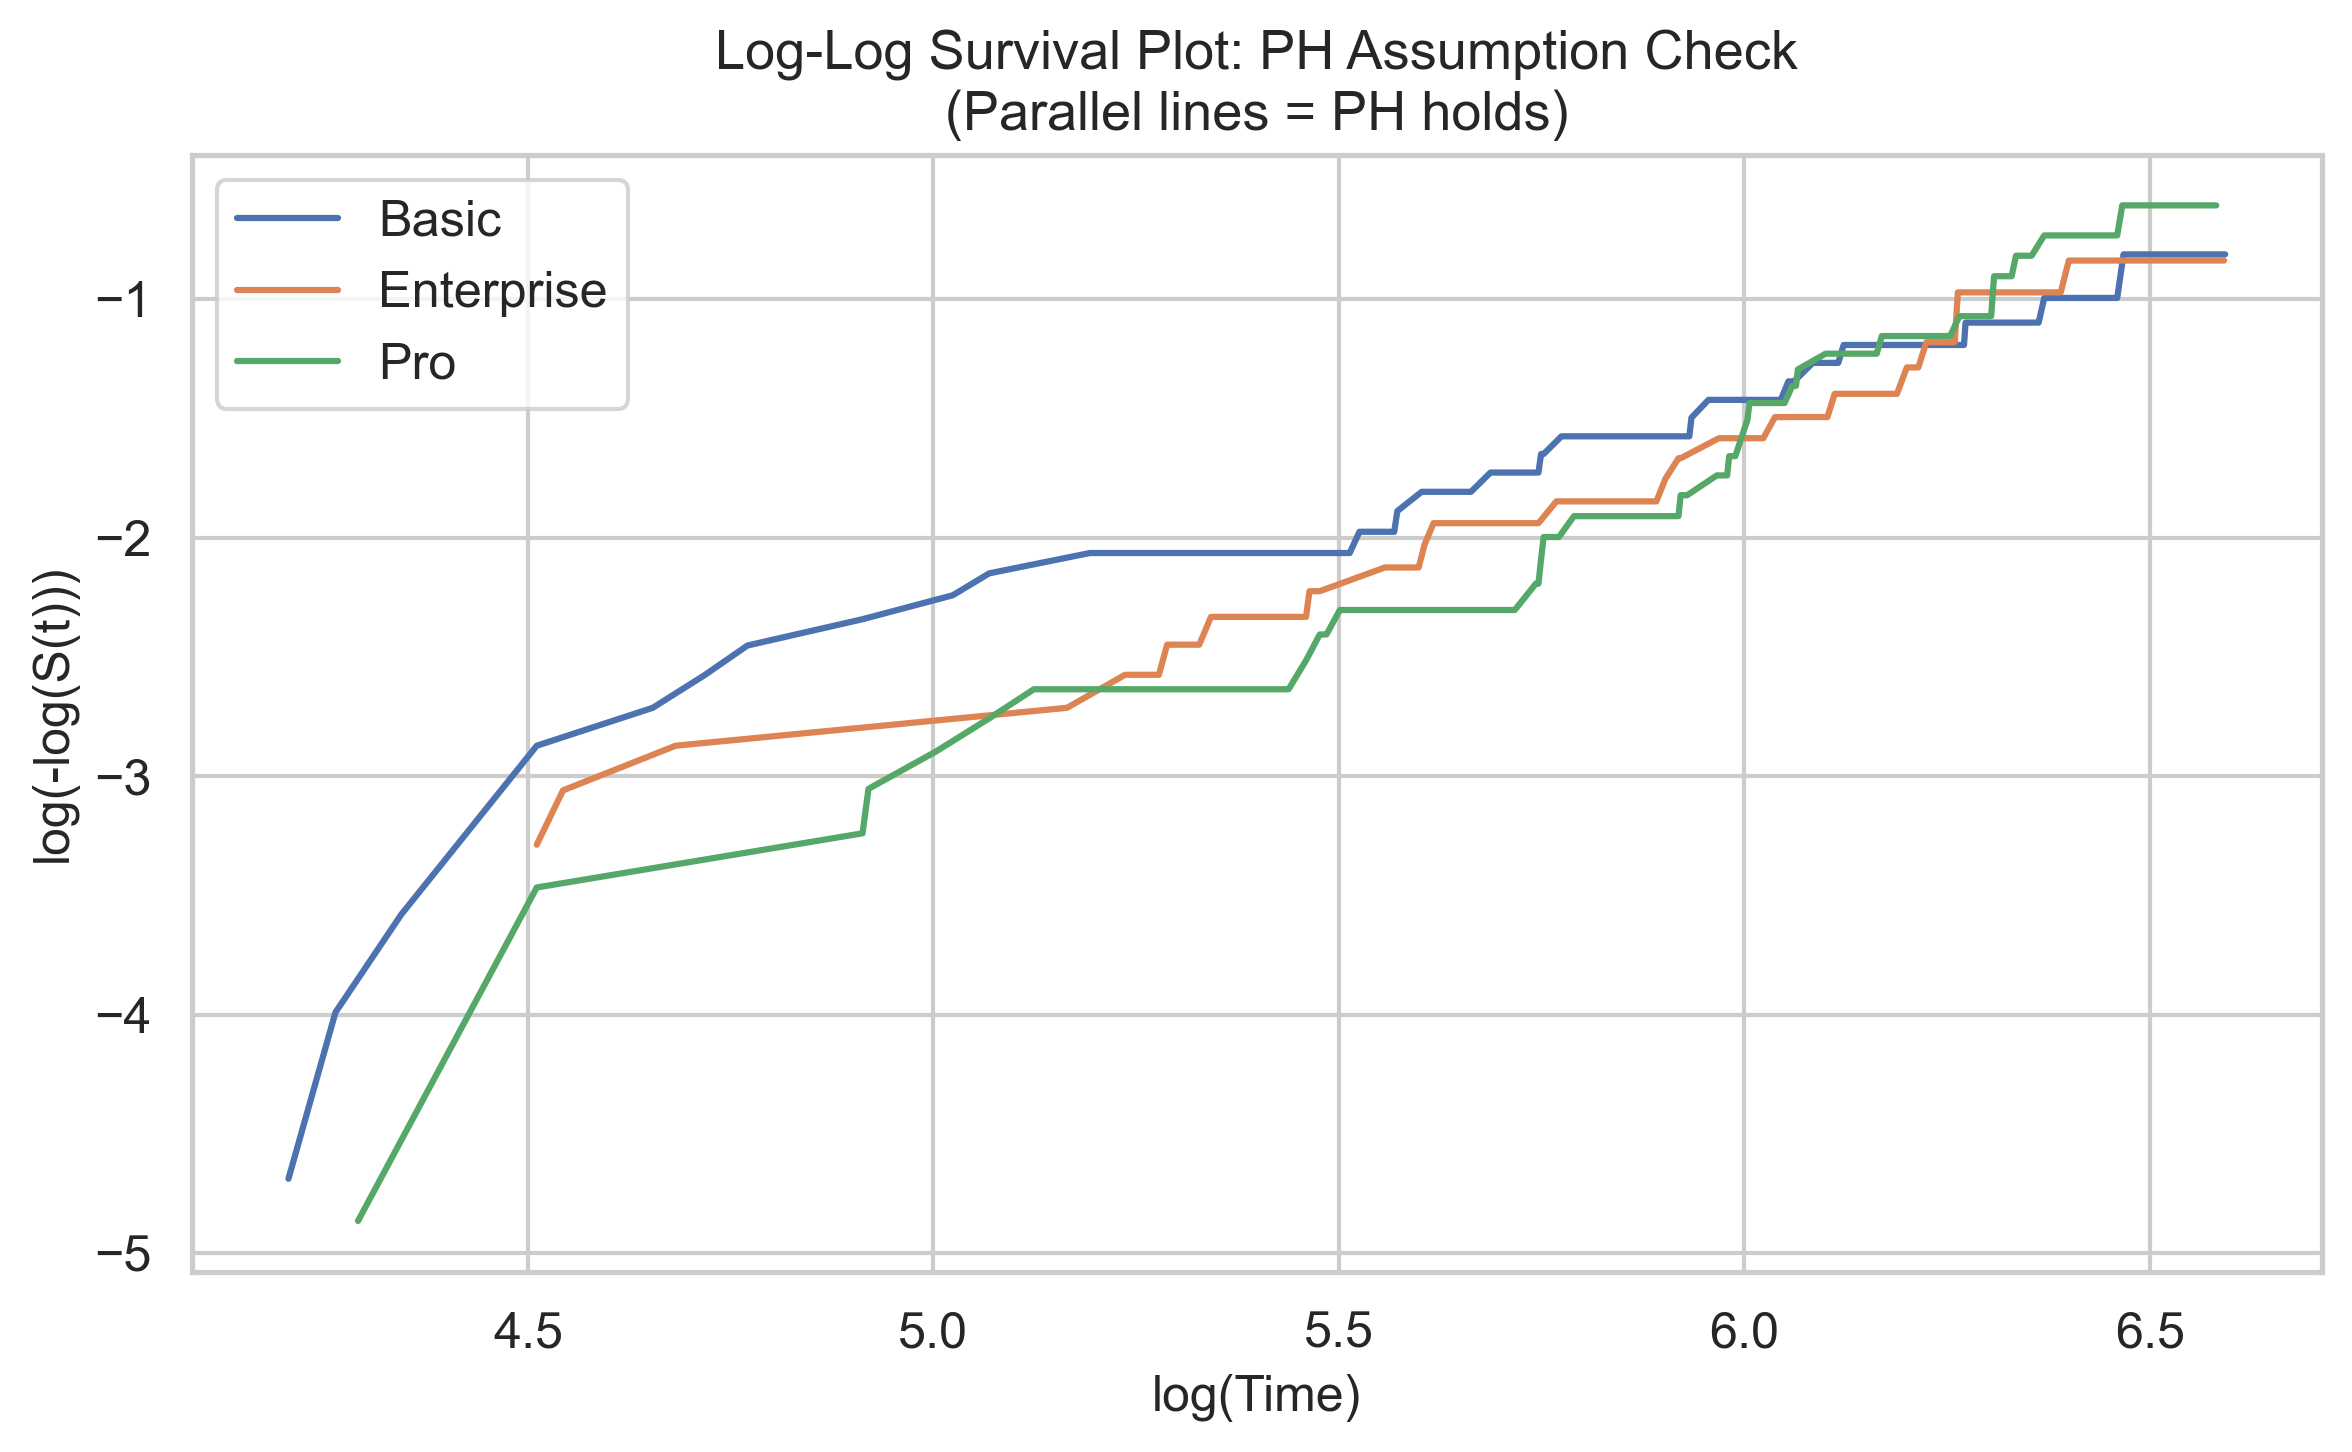

If lines are approximately parallel, the proportional hazards assumption holds.
Non-parallel lines suggest the effect of plan_tier varies over time.


In [10]:
# Log-log survival plot for visual PH check
fig, ax = plt.subplots(figsize=(8, 5))

for tier in train_df["plan_tier"].unique():
    mask = train_df["plan_tier"] == tier
    kmf_tier = KaplanMeierFitter()
    kmf_tier.fit(
        durations=train_df.loc[mask, "duration_days"],
        event_observed=train_df.loc[mask, "event_observed"],
        label=f"{tier} ({tier_map.get(tier, tier)})",
    )
    # Plot log(-log(S(t))) vs log(t)
    sf = kmf_tier.survival_function_
    sf = sf[sf.iloc[:, 0] > 0]  # Avoid log(0)
    log_time = np.log(sf.index + 1)  # +1 to avoid log(0)
    log_neg_log_s = np.log(-np.log(sf.iloc[:, 0]))
    ax.plot(log_time, log_neg_log_s, label=f"{tier}")

ax.set_xlabel("log(Time)", fontsize=12)
ax.set_ylabel("log(-log(S(t)))", fontsize=12)
ax.set_title("Log-Log Survival Plot: PH Assumption Check\n(Parallel lines = PH holds)", fontsize=13)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "log_log_survival_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("If lines are approximately parallel, the proportional hazards assumption holds.")
print("Non-parallel lines suggest the effect of plan_tier varies over time.")

---
## 6. Cox vs. LightGBM Survival Comparison

We compare the interpretable Cox model against a Gradient Boosting Survival model to assess the interpretability-performance tradeoff.

**Decision criterion from spec:** If LightGBM C-index > Cox C-index + 0.05, use LightGBM for operational predictions and Cox for stakeholder interpretation. If the difference is < 0.05, use Cox for both (simplicity wins).

This comparison demonstrates nuanced ML judgment -- knowing when interpretability matters more than marginal performance gains.

In [11]:
# Fit Gradient Boosting Survival Analysis model
gbsa_model = sa.fit_gbsa(
    X_train_all,
    y_train,
    feature_names=selected_features,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_samples_split=10,
    min_samples_leaf=5,
)

# Compare on test set
comparison = sa.compare_cox_vs_gbsa(X_test_all, y_test)

print("\n" + "=" * 70)
print("  COX PH vs. GRADIENT BOOSTING SURVIVAL: HEAD-TO-HEAD COMPARISON")
print("=" * 70)
print(f"\n{'Metric':<25} {'Cox PH':<15} {'GBSA':<15} {'Difference':<15}")
print("-" * 70)
print(f"{'C-index':<25} {comparison['cox']['c_index']:<15.4f} {comparison['gbsa']['c_index']:<15.4f} {comparison['c_index_difference']:<+15.4f}")
print(f"{'IBS':<25} {comparison['cox']['ibs']:<15.4f} {comparison['gbsa']['ibs']:<15.4f} {comparison['gbsa']['ibs'] - comparison['cox']['ibs']:<+15.4f}")
print(f"{'Interpretability':<25} {'High (HR)':<15} {'Low (black-box)':<15}")
print(f"\nDecision threshold: {comparison['threshold']}")
print(f"C-index difference: {comparison['c_index_difference']:+.4f}")
print(f"\nPreferred model: {comparison['preferred_model'].upper()}")
print(f"Recommendation: {comparison['recommendation']}")


  COX PH vs. GRADIENT BOOSTING SURVIVAL: HEAD-TO-HEAD COMPARISON

Metric                    Cox PH          GBSA            Difference     
----------------------------------------------------------------------
C-index                   0.3976          0.5179          +0.1203        
IBS                       0.0823          0.0792          -0.0031        
Interpretability          High (HR)       Low (black-box)

Decision threshold: 0.05
C-index difference: +0.1203

Preferred model: GBSA
Recommendation: GBSA C-index exceeds Cox by 0.120 (>0.05). Use GBSA for operational predictions, Cox for stakeholder interpretation (hazard ratios).


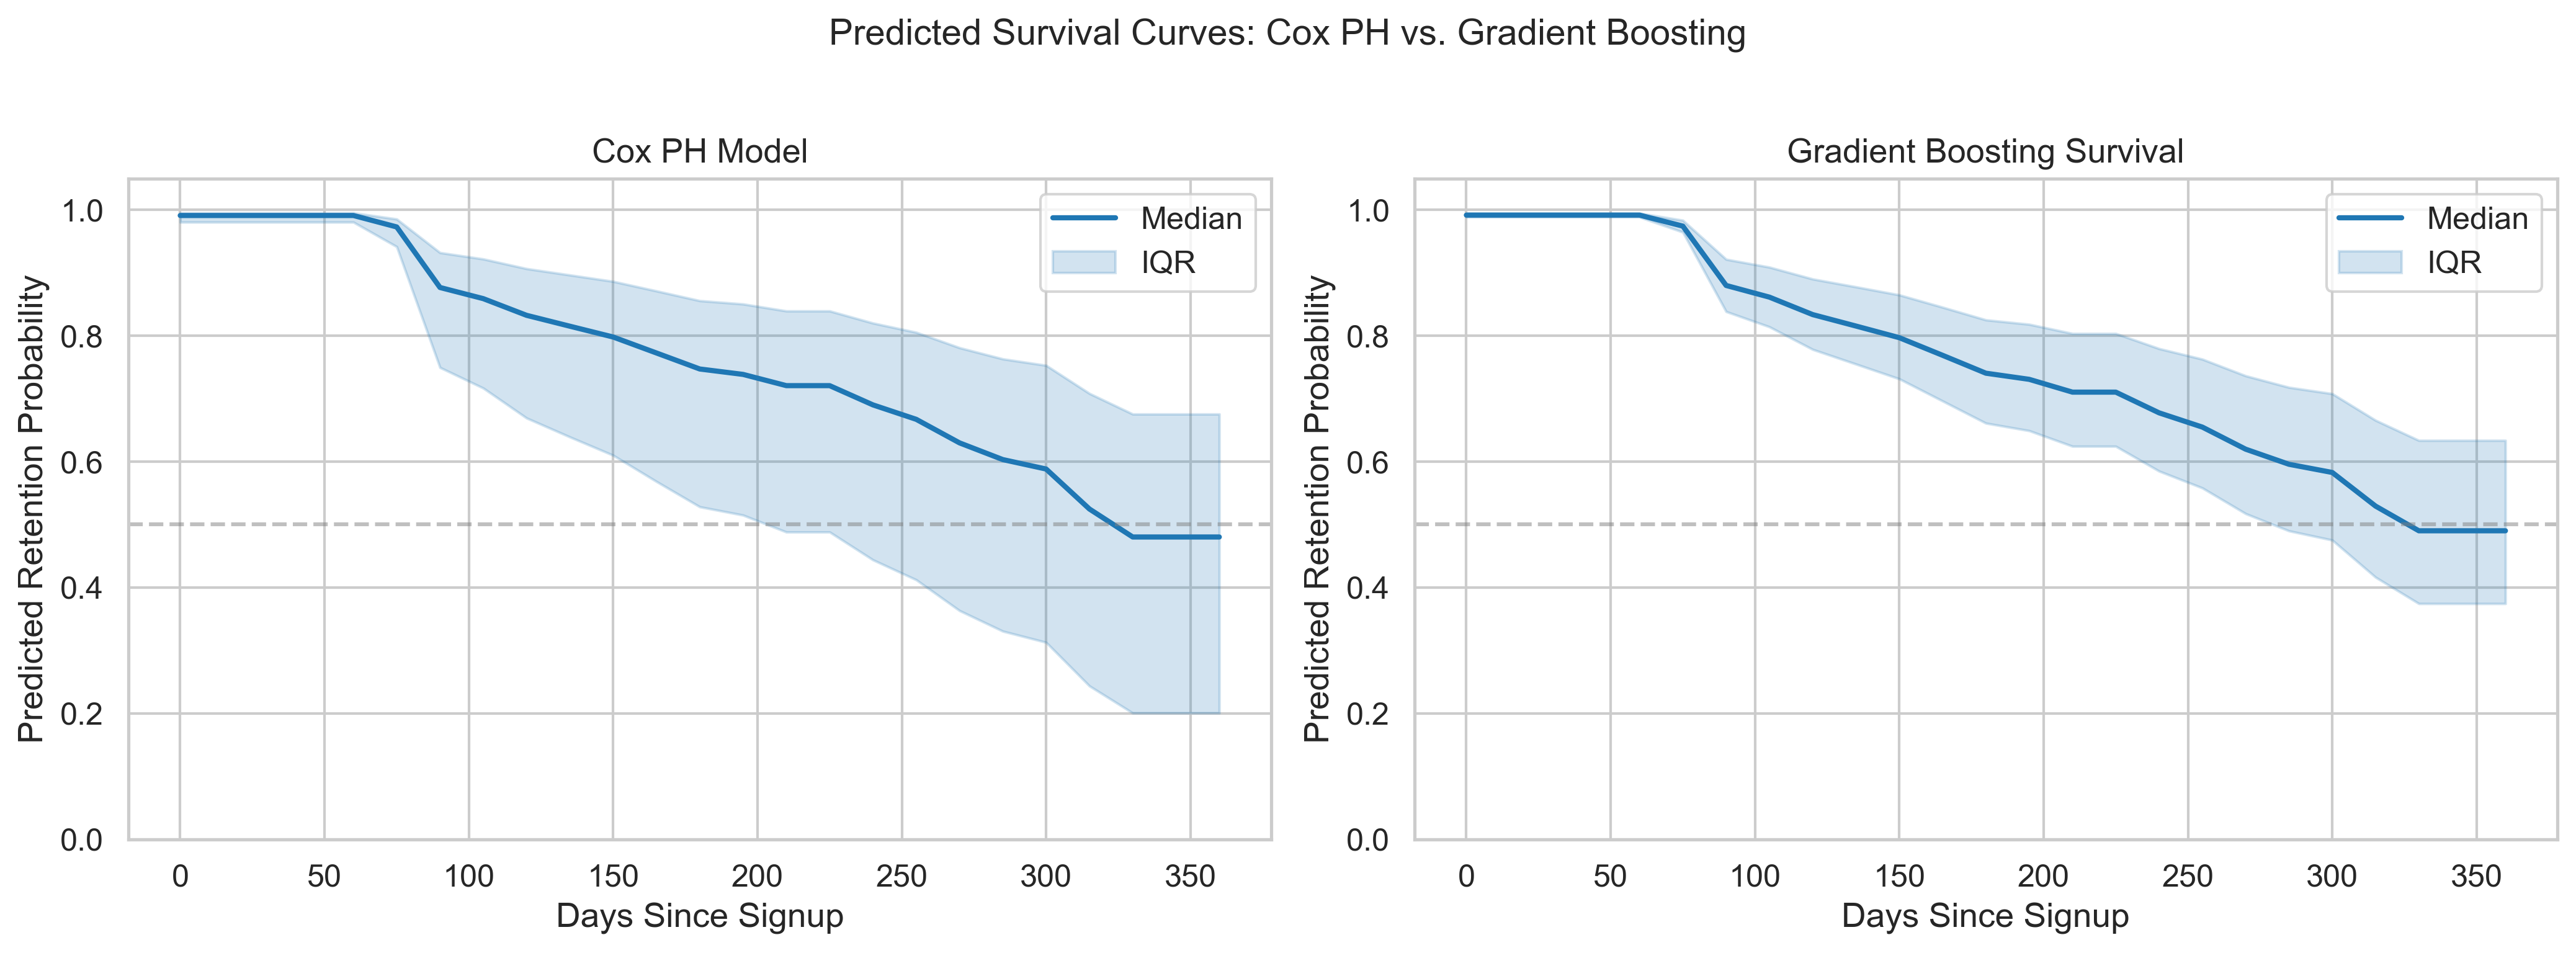

In [12]:
# Side-by-side survival curves from both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
time_grid = np.arange(0, 366, 15)

for ax, model, title in [
    (axes[0], sa.cox_model, "Cox PH Model"),
    (axes[1], sa.gbsa_model, "Gradient Boosting Survival"),
]:
    tg, surv_matrix = sa.get_survival_curves(model, X_test_all, time_grid)
    
    # Plot median curve with confidence band
    median_curve = np.median(surv_matrix, axis=0)
    q25 = np.percentile(surv_matrix, 25, axis=0)
    q75 = np.percentile(surv_matrix, 75, axis=0)
    
    ax.plot(tg, median_curve, color="#1f77b4", linewidth=2, label="Median")
    ax.fill_between(tg, q25, q75, alpha=0.2, color="#1f77b4", label="IQR")
    ax.axhline(y=0.5, color="grey", linestyle="--", alpha=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Days Since Signup")
    ax.set_ylabel("Predicted Retention Probability")
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.suptitle("Predicted Survival Curves: Cox PH vs. Gradient Boosting", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "cox_vs_gbsa_survival_curves.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 7. LTV Revenue Modeling

The survival model tells us WHEN players churn, but not HOW MUCH they spend. For pLTV, we need a revenue prediction model.

**Approach:**
- Target: `total_revenue_180d` (actual 180-day revenue from subscription data)
- Primary model: LightGBM regressor, tuned with Optuna (20 trials)
- Baselines: cohort average LTV, random forest regressor
- Metrics: RMSE, MAPE (target < 25%), R-squared (target > 0.60)

In [13]:
# Prepare revenue targets
y_train_rev = train_df["total_revenue_180d"].values
y_val_rev = val_df["total_revenue_180d"].values
y_test_rev = test_df["total_revenue_180d"].values

print(f"Revenue distribution (train):")
print(f"  Mean:   GBP {y_train_rev.mean():.0f}")
print(f"  Median: GBP {np.median(y_train_rev):.0f}")
print(f"  Std:    GBP {y_train_rev.std():.0f}")
print(f"  Min:    GBP {y_train_rev.min():.0f}")
print(f"  Max:    GBP {y_train_rev.max():.0f}")
print(f"  Zero-revenue: {(y_train_rev == 0).sum()} ({(y_train_rev == 0).mean():.1%})")

Revenue distribution (train):
  Mean:   GBP 1056
  Median: GBP 745
  Std:    GBP 1102
  Min:    GBP 0
  Max:    GBP 7594
  Zero-revenue: 19 (5.5%)


In [14]:
# Initialize LTV Predictor
ltv = LTVPredictor(config)

# Baseline 1: Cohort average LTV
ltv.fit_cohort_baseline(train_df)
cohort_preds_test = ltv.predict_cohort_baseline(test_df)
cohort_metrics = ltv.evaluate_regression(y_test_rev, cohort_preds_test, "Cohort Baseline")

# Baseline 2: Random Forest
ltv.fit_random_forest_baseline(X_train_all, y_train_rev, feature_names=selected_features)
rf_preds_test = ltv.predict(ltv.rf_model, X_test_all, feature_names=selected_features)
rf_metrics = ltv.evaluate_regression(y_test_rev, rf_preds_test, "Random Forest")

print("\nBaseline model performance on test set:")
print(f"{'Model':<20} {'RMSE':>8} {'MAPE':>8} {'R2':>8}")
print("-" * 46)
print(f"{'Cohort Average':<20} {cohort_metrics['rmse']:>8.1f} {cohort_metrics['mape']*100:>7.1f}% {cohort_metrics['r_squared']:>8.4f}")
print(f"{'Random Forest':<20} {rf_metrics['rmse']:>8.1f} {rf_metrics['mape']*100:>7.1f}% {rf_metrics['r_squared']:>8.4f}")


Baseline model performance on test set:
Model                    RMSE     MAPE       R2
----------------------------------------------
Cohort Average         2323.6    75.3%  -0.5610
Random Forest          1637.8    91.0%   0.2244


In [15]:
# Tune LightGBM with Optuna
n_trials = config["models"]["lightgbm_survival"]["tuning"]["n_trials"]
print(f"Running Optuna hyperparameter tuning ({n_trials} trials)...")

best_params = ltv.tune_lightgbm(
    X_train_all,
    y_train_rev,
    X_val_all,
    y_val_rev,
    feature_names=selected_features,
    n_trials=n_trials,
)

print(f"\nBest hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

Running Optuna hyperparameter tuning (20 trials)...

Best hyperparameters:
  num_leaves: 68
  learning_rate: 0.0835361075531176
  max_depth: 4
  min_child_samples: 18
  n_estimators: 118
  subsample: 0.7301321323053057
  colsample_bytree: 0.7554709158757928
  reg_alpha: 2.7678419414850017e-06
  reg_lambda: 0.28749982347407854


In [16]:
# Fit final LightGBM model with best params
ltv.fit_lightgbm(X_train_all, y_train_rev, feature_names=selected_features)
lgb_preds_test = ltv.predict(ltv.lgb_model, X_test_all, feature_names=selected_features)
lgb_metrics = ltv.evaluate_regression(y_test_rev, lgb_preds_test, "LightGBM")

# Final comparison table
targets = config["evaluation"]["ltv_metrics"]
print("\n" + "=" * 65)
print("  LTV MODEL COMPARISON (Test Set)")
print("=" * 65)
print(f"{'Model':<20} {'RMSE':>8} {'MAPE':>8} {'R2':>8}  Target")
print("-" * 65)
print(f"{'Cohort Average':<20} {cohort_metrics['rmse']:>8.1f} {cohort_metrics['mape']*100:>7.1f}% {cohort_metrics['r_squared']:>8.4f}  (naive baseline)")
print(f"{'Random Forest':<20} {rf_metrics['rmse']:>8.1f} {rf_metrics['mape']*100:>7.1f}% {rf_metrics['r_squared']:>8.4f}  (ensemble baseline)")
print(f"{'LightGBM (tuned)':<20} {lgb_metrics['rmse']:>8.1f} {lgb_metrics['mape']*100:>7.1f}% {lgb_metrics['r_squared']:>8.4f}  <{targets['rmse']['target']}, <{targets['mape']['target']*100}%, >{targets['r_squared']['target']}")


  LTV MODEL COMPARISON (Test Set)
Model                    RMSE     MAPE       R2  Target
-----------------------------------------------------------------
Cohort Average         2323.6    75.3%  -0.5610  (naive baseline)
Random Forest          1637.8    91.0%   0.2244  (ensemble baseline)
LightGBM (tuned)       1819.4    87.6%   0.0429  <1200.0, <25.0%, >0.6


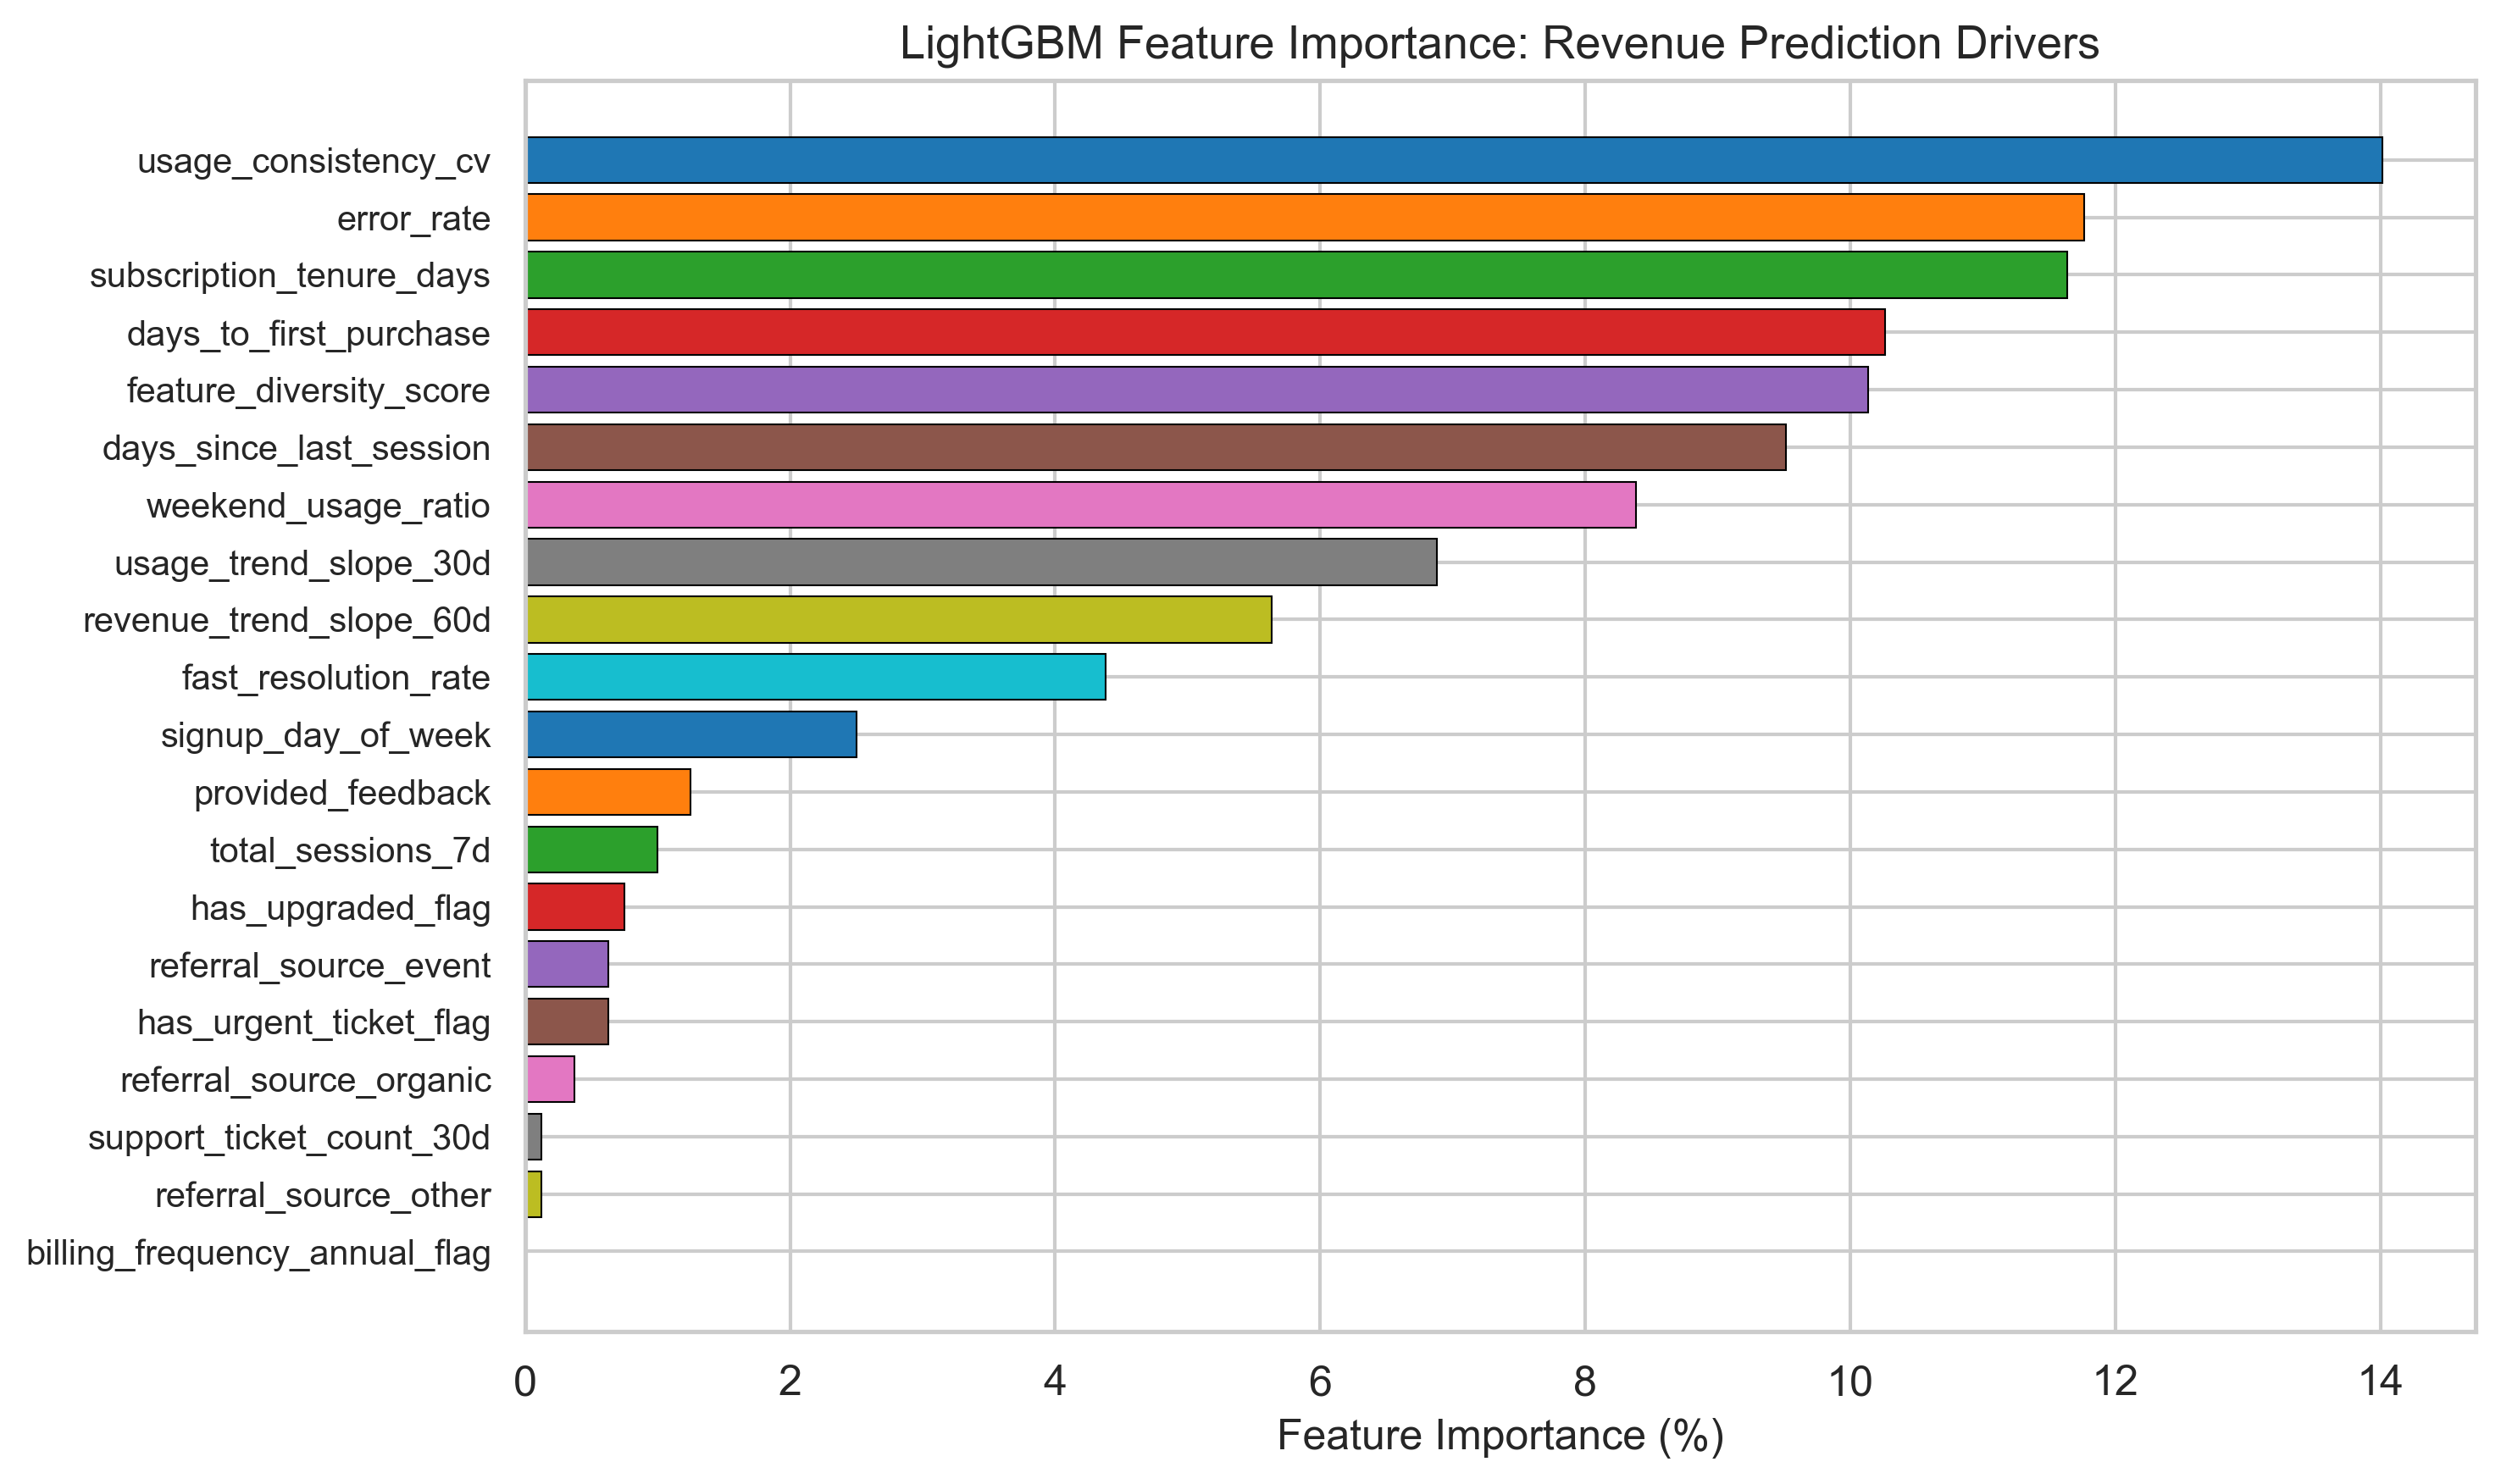

Top 5 features driving revenue prediction:
  usage_consistency_cv: 14.0%
  error_rate: 11.8%
  subscription_tenure_days: 11.6%
  days_to_first_purchase: 10.3%
  feature_diversity_score: 10.1%


In [17]:
# Feature importance from LightGBM
fi_df = ltv.get_feature_importance(ltv.lgb_model, selected_features)

fig, ax = plt.subplots(figsize=(10, max(5, len(fi_df) * 0.3)))
fi_top = fi_df.head(20)
ax.barh(
    range(len(fi_top)),
    fi_top["importance_pct"],
    color=sns.color_palette(PALETTE, len(fi_top)),
    edgecolor="black",
    linewidth=0.5,
)
ax.set_yticks(range(len(fi_top)))
ax.set_yticklabels(fi_top["feature"], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (%)", fontsize=12)
ax.set_title("LightGBM Feature Importance: Revenue Prediction Drivers", fontsize=13)

plt.tight_layout()
fig.savefig(FIG_DIR / "feature_importance_ltv.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top 5 features driving revenue prediction:")
for _, row in fi_top.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance_pct']:.1f}%")

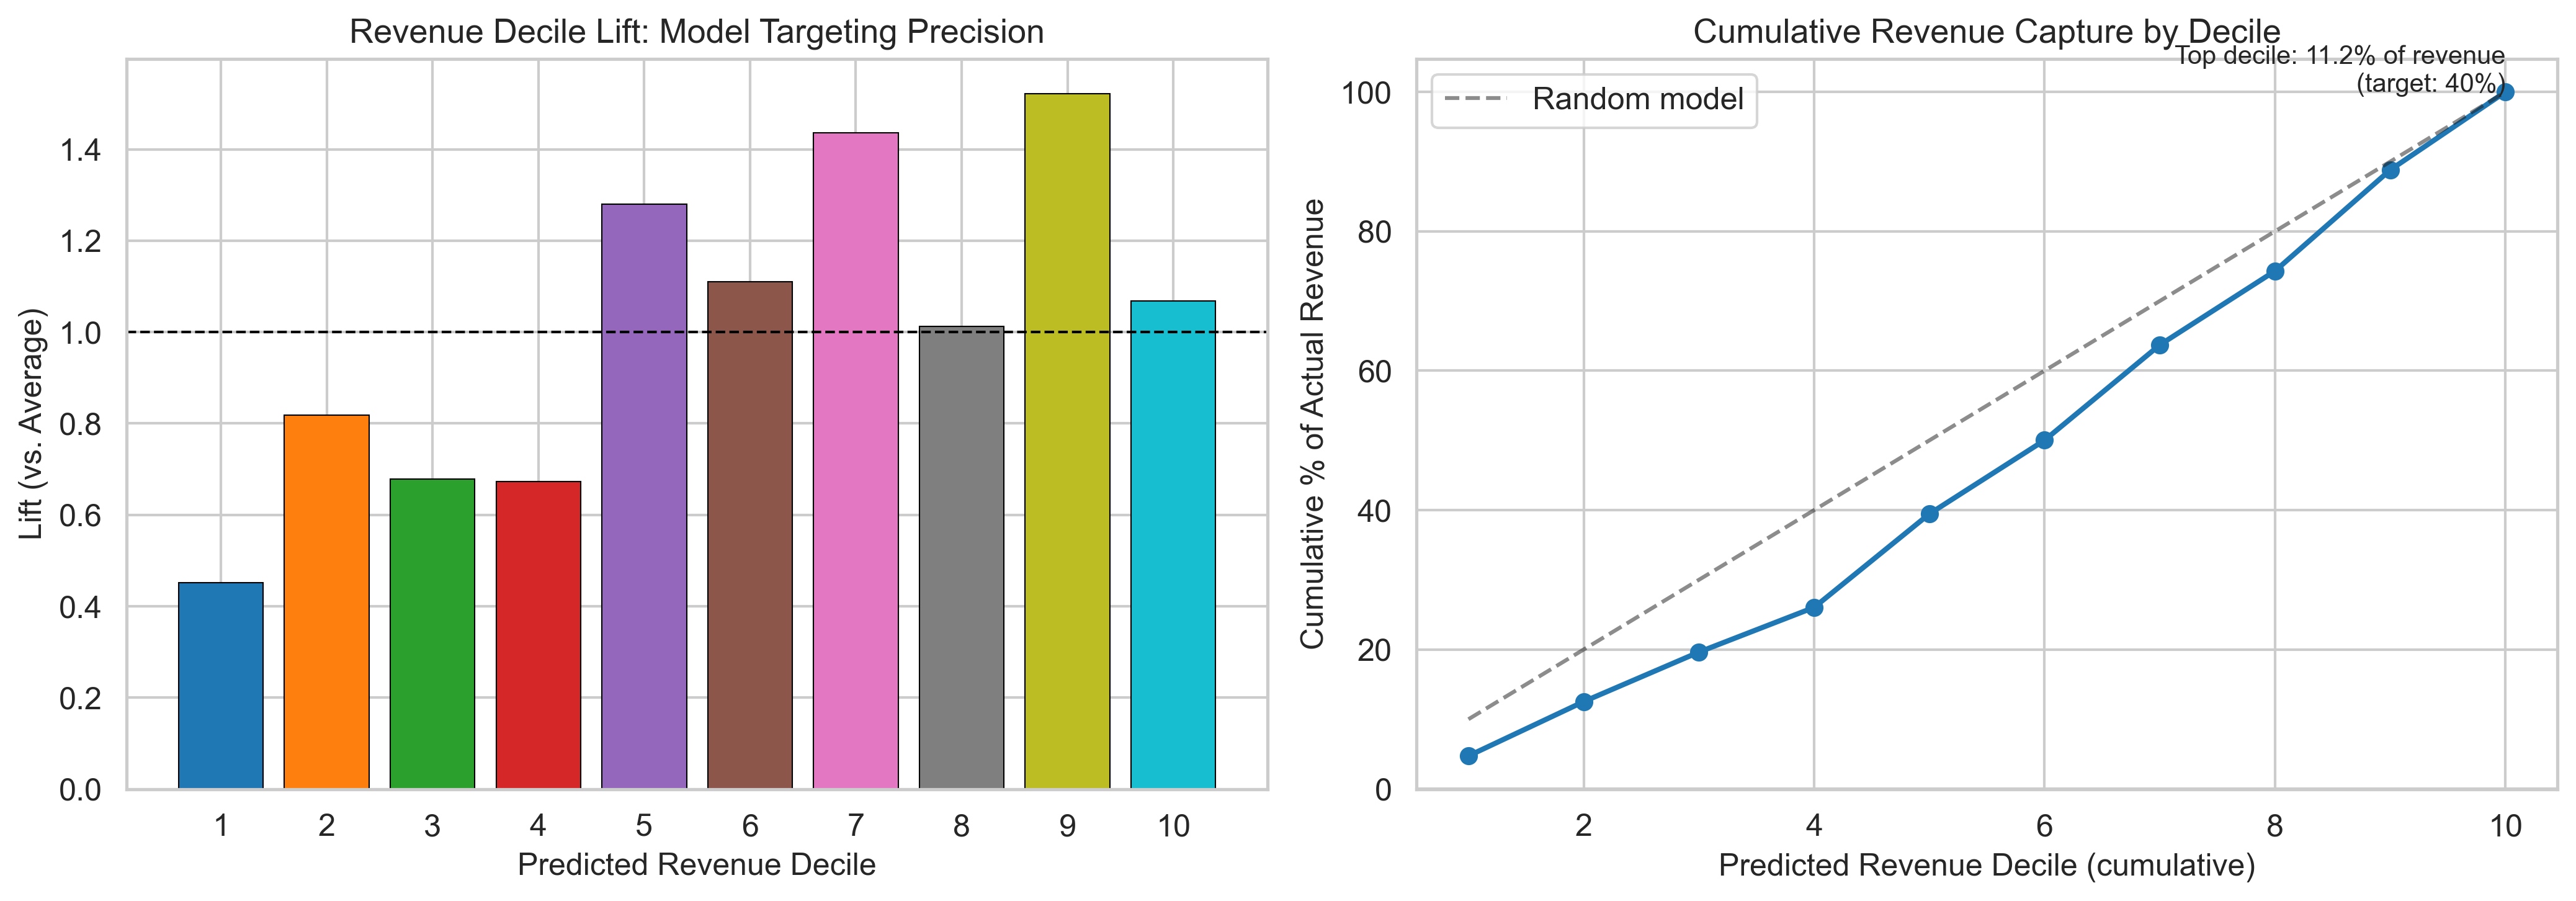


Top decile captures 11.2% of total revenue (target: 40%)
Top 2 deciles capture 25.7% of total revenue


In [18]:
# Revenue decile lift analysis
decile_df = ltv.compute_decile_lift(y_test_rev, lgb_preds_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decile lift bars
axes[0].bar(
    decile_df["decile"].astype(str),
    decile_df["lift"],
    color=sns.color_palette(PALETTE, len(decile_df)),
    edgecolor="black",
    linewidth=0.5,
)
axes[0].axhline(y=1.0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted Revenue Decile", fontsize=12)
axes[0].set_ylabel("Lift (vs. Average)", fontsize=12)
axes[0].set_title("Revenue Decile Lift: Model Targeting Precision", fontsize=13)

# Cumulative revenue capture
axes[1].plot(
    decile_df["decile"].astype(int),
    decile_df["cumulative_pct"] * 100,
    marker="o",
    color="#1f77b4",
    linewidth=2,
    markersize=6,
)
axes[1].plot(
    range(1, 11), np.linspace(10, 100, 10), "k--", alpha=0.5, label="Random model"
)
axes[1].set_xlabel("Predicted Revenue Decile (cumulative)", fontsize=12)
axes[1].set_ylabel("Cumulative % of Actual Revenue", fontsize=12)
axes[1].set_title("Cumulative Revenue Capture by Decile", fontsize=13)
axes[1].legend()

target_decile = config["evaluation"]["ltv_metrics"]["decile_lift"]["target_top_decile_revenue_share"]
top_decile_pct = decile_df.loc[decile_df["decile"].astype(int) == 10, "revenue_pct"].values[0]
axes[1].annotate(
    f"Top decile: {top_decile_pct*100:.1f}% of revenue\n(target: {target_decile*100:.0f}%)",
    xy=(10, decile_df["cumulative_pct"].iloc[-1] * 100),
    fontsize=10,
    ha="right",
)

plt.tight_layout()
fig.savefig(FIG_DIR / "ltv_decile_lift.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nTop decile captures {top_decile_pct*100:.1f}% of total revenue (target: {target_decile*100:.0f}%)")
print(f"Top 2 deciles capture {decile_df.tail(2)['revenue_pct'].sum()*100:.1f}% of total revenue")

---
## 8. Combined pLTV Framework

The predicted Lifetime Value combines both models:

$$\text{pLTV} = P(\text{survive 180 days} \mid \text{Cox}) \times E(\text{revenue} \mid \text{LightGBM})$$

This is the final output that the UA team uses for bid optimization: players with high pLTV justify higher acquisition costs, while low-pLTV players should be deprioritized.

In [19]:
# Calculate pLTV
pltv_calc = PLTVCalculator(sa, ltv, config)
pltv_df = pltv_calc.calculate_pltv(X_test_all)

# Add original context for segmentation
pltv_df["actual_revenue"] = y_test_rev
pltv_df["actual_churn"] = test_df["event_observed"].values

print("pLTV Distribution (Test Set):")
print(f"  Mean:   GBP {pltv_df['pltv'].mean():.0f}")
print(f"  Median: GBP {pltv_df['pltv'].median():.0f}")
print(f"  Std:    GBP {pltv_df['pltv'].std():.0f}")
print(f"  Min:    GBP {pltv_df['pltv'].min():.0f}")
print(f"  Max:    GBP {pltv_df['pltv'].max():.0f}")
print(f"\nComponent stats:")
print(f"  Survival prob (180d): mean={pltv_df['survival_prob_180d'].mean():.3f}, "
      f"median={pltv_df['survival_prob_180d'].median():.3f}")
print(f"  Predicted revenue:    mean=GBP {pltv_df['predicted_revenue'].mean():.0f}, "
      f"median=GBP {pltv_df['predicted_revenue'].median():.0f}")

pLTV Distribution (Test Set):
  Mean:   GBP 1285
  Median: GBP 1305
  Std:    GBP 687
  Min:    GBP 0
  Max:    GBP 3271

Component stats:
  Survival prob (180d): mean=0.662, median=0.747
  Predicted revenue:    mean=GBP 1909, median=GBP 2001


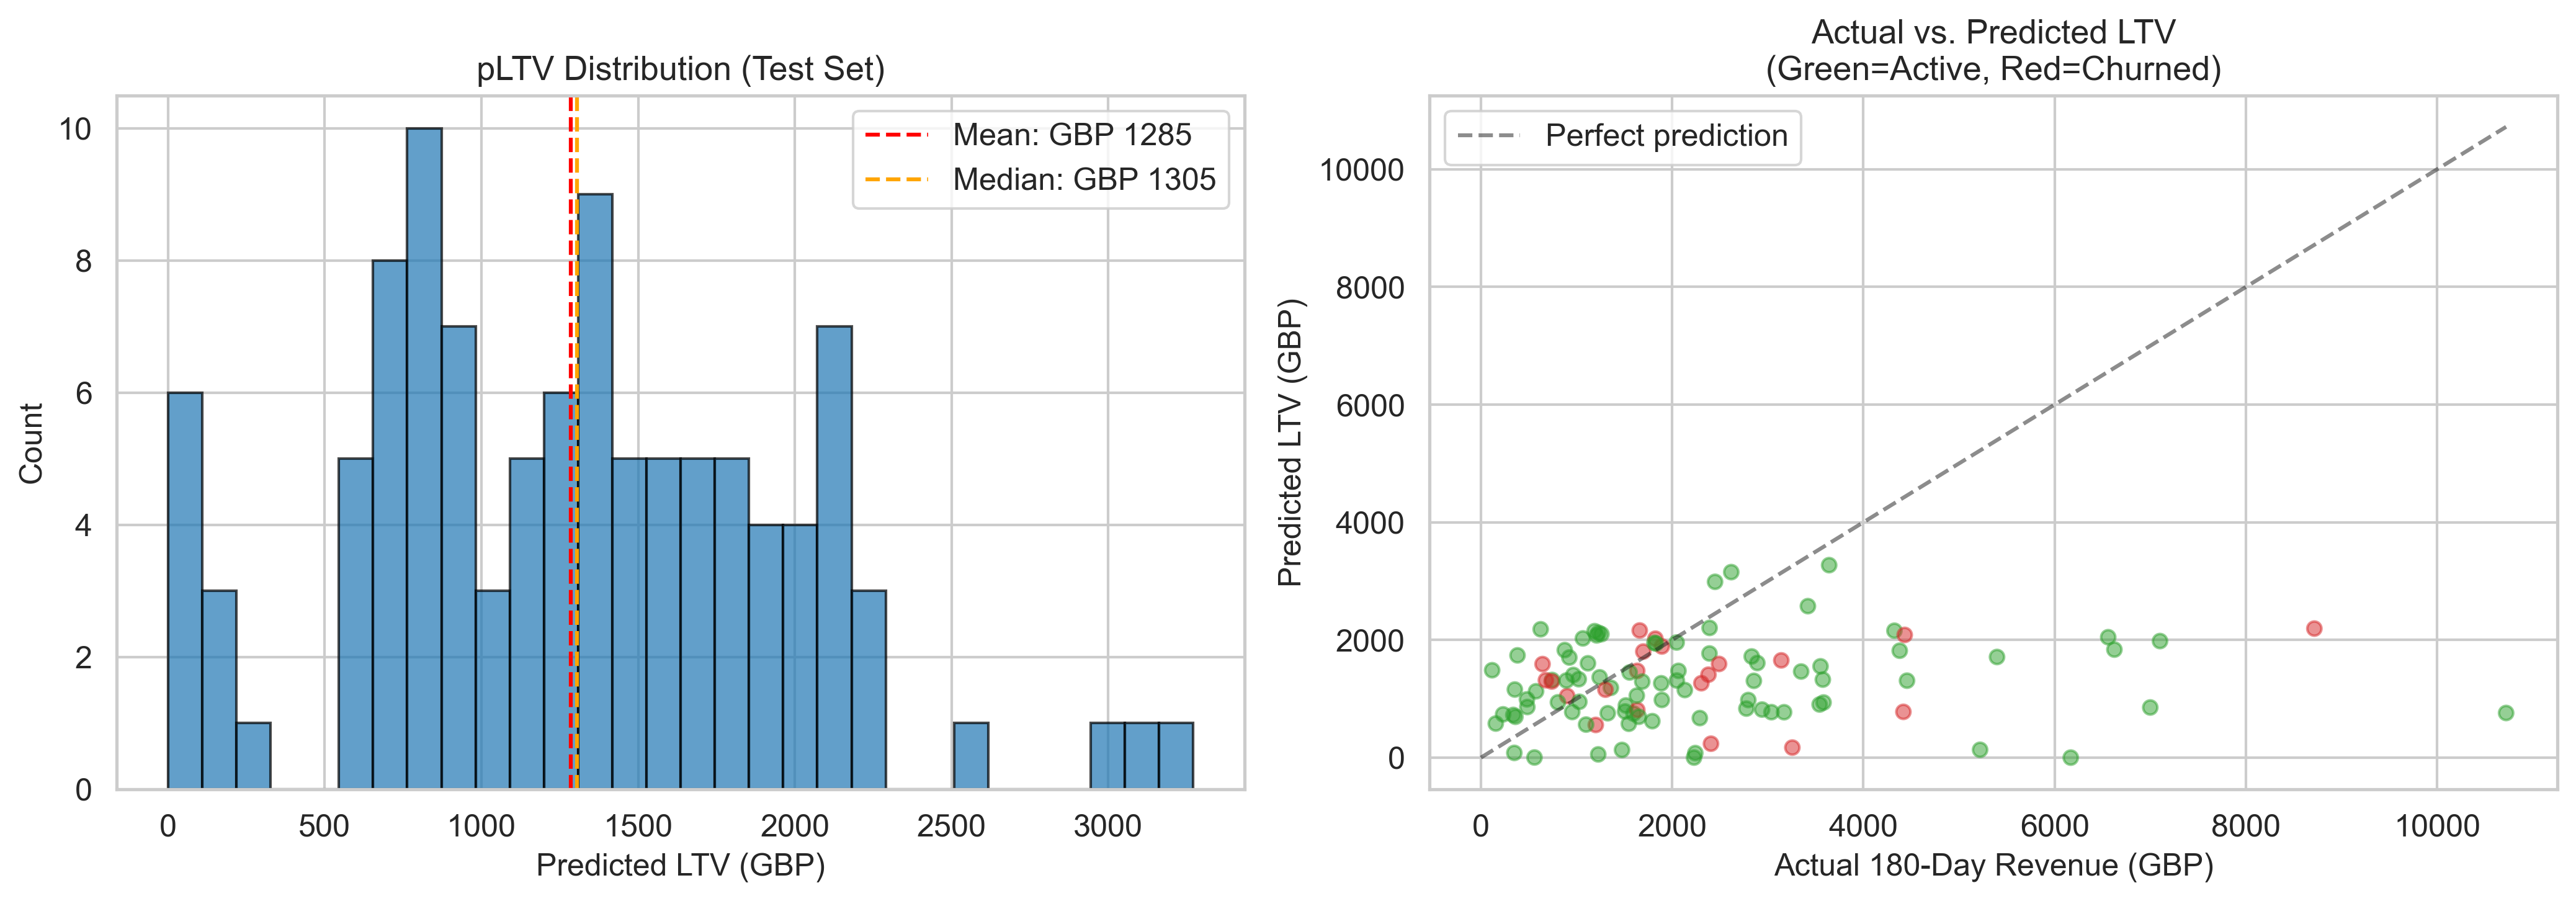

In [20]:
# pLTV distribution and actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(
    pltv_df["pltv"],
    bins=30,
    color="#1f77b4",
    edgecolor="black",
    alpha=0.7,
)
axes[0].axvline(pltv_df["pltv"].mean(), color="red", linestyle="--", label=f"Mean: GBP {pltv_df['pltv'].mean():.0f}")
axes[0].axvline(pltv_df["pltv"].median(), color="orange", linestyle="--", label=f"Median: GBP {pltv_df['pltv'].median():.0f}")
axes[0].set_xlabel("Predicted LTV (GBP)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("pLTV Distribution (Test Set)", fontsize=13)
axes[0].legend()

# Actual vs Predicted scatter
axes[1].scatter(
    pltv_df["actual_revenue"],
    pltv_df["pltv"],
    alpha=0.5,
    c=pltv_df["actual_churn"].map({0: "#2ca02c", 1: "#d62728"}),
    s=30,
)
max_val = max(pltv_df["actual_revenue"].max(), pltv_df["pltv"].max())
axes[1].plot([0, max_val], [0, max_val], "k--", alpha=0.5, label="Perfect prediction")
axes[1].set_xlabel("Actual 180-Day Revenue (GBP)", fontsize=12)
axes[1].set_ylabel("Predicted LTV (GBP)", fontsize=12)
axes[1].set_title("Actual vs. Predicted LTV\n(Green=Active, Red=Churned)", fontsize=13)
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "pltv_distribution_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Segment analysis by plan tier
tier_analysis = pltv_calc.segment_analysis(pltv_df, test_df, "plan_tier")
print("pLTV by Subscription Tier:")
tier_analysis

pLTV by Subscription Tier:


,plan_tier,pltv_mean,pltv_median,pltv_std,count,pltv_total,pct_of_total
0,Basic,1334.622522,1306.042987,613.498894,42,56054.145936,41.529844
1,Enterprise,1029.940338,852.066268,658.495805,31,31928.150475,23.655183
2,Pro,1468.464728,1480.138396,748.702422,32,46990.871297,34.814973


In [22]:
# Segment analysis by referral source
channel_analysis = pltv_calc.segment_analysis(pltv_df, test_df, "referral_source")
print("pLTV by Acquisition Channel:")
channel_analysis

pLTV by Acquisition Channel:


,referral_source,pltv_mean,pltv_median,pltv_std,count,pltv_total,pct_of_total
0,ads,1308.374103,1310.370499,570.552058,13,17008.863339,12.601663
1,event,1026.138968,886.594753,818.882183,23,23601.196263,17.485843
2,organic,1474.211794,1404.871046,668.736395,29,42752.142016,31.674549
3,other,1191.176323,1310.243772,645.578420,21,25014.702773,18.533093
4,partner,1399.803333,1325.869440,599.844156,19,26596.263318,19.704852


---
## 9. Business Validation & Model Summary

### Retention Intervention Simulation

If the UA team sends a GBP 5 retention offer to the top 20% highest churn risk players, what is the expected ROI?

In [23]:
# Retention intervention simulation
sim = pltv_calc.simulate_retention_intervention(pltv_df)

print("Retention Intervention Simulation:")
print("=" * 50)
print(f"  Players targeted (top 20% risk): {sim['n_targeted']}")
print(f"  Offer value:                     GBP {sim['offer_value_gbp']:.2f}")
print(f"  Total cost:                      GBP {sim['total_cost_gbp']:.2f}")
print(f"  Expected retention uplift:        {sim['retention_uplift_pct']:.0f}%")
print(f"  Players saved from churn:         {sim['n_saved']}")
print(f"  Expected revenue from saved:      GBP {sim['expected_revenue_gbp']:.2f}")
print(f"  Net benefit:                     GBP {sim['net_benefit_gbp']:.2f}")
print(f"  ROI:                             {sim['roi_pct']:.0f}%")
print(f"\nTarget ROI: > {config['business_validation']['retention_offer_simulation']['target_roi']*100:.0f}%")

Retention Intervention Simulation:
  Players targeted (top 20% risk): 21
  Offer value:                     GBP 5.00
  Total cost:                      GBP 105.00
  Expected retention uplift:        15%
  Players saved from churn:         3
  Expected revenue from saved:      GBP 54.00
  Net benefit:                     GBP -51.00
  ROI:                             -49%

Target ROI: > 200%


In [24]:
# Save all models
save_model(
    sa.cox_model,
    str(MODEL_DIR / "cox_ph_model.joblib"),
    {
        "model_type": "CoxPHSurvivalAnalysis",
        "features": selected_features,
        "test_c_index": cox_test_metrics["c_index"],
        "test_ibs": cox_test_metrics["ibs"],
        "penalizer": sa.penalizer,
    },
)

save_model(
    sa.gbsa_model,
    str(MODEL_DIR / "gbsa_model.joblib"),
    {
        "model_type": "GradientBoostingSurvivalAnalysis",
        "features": selected_features,
        "test_c_index": comparison["gbsa"]["c_index"],
        "test_ibs": comparison["gbsa"]["ibs"],
    },
)

save_model(
    ltv.lgb_model,
    str(MODEL_DIR / "lgb_ltv_model.joblib"),
    {
        "model_type": "LGBMRegressor",
        "features": selected_features,
        "best_params": ltv.best_params_,
        "test_rmse": lgb_metrics["rmse"],
        "test_mape": lgb_metrics["mape"],
        "test_r_squared": lgb_metrics["r_squared"],
    },
)

save_model(
    ltv.rf_model,
    str(MODEL_DIR / "rf_baseline_model.joblib"),
    {
        "model_type": "RandomForestRegressor",
        "features": selected_features,
        "test_rmse": rf_metrics["rmse"],
    },
)

# Save scaler and feature list for inference
import joblib
joblib.dump(sa.scaler, str(MODEL_DIR / "feature_scaler.joblib"))
joblib.dump(selected_features, str(MODEL_DIR / "selected_features.joblib"))

print(f"All models saved to {MODEL_DIR}")
print(f"Model artifacts: {[f.name for f in MODEL_DIR.iterdir()]}")

All models saved to c:\Users\matt_\Documents\Projects\Data Science\career-development\portfolio-projects\player_ltv_survival_analysis\outputs\models
Model artifacts: ['cox_ph_model.joblib', 'cox_ph_model.json', 'feature_scaler.joblib', 'gbsa_model.joblib', 'gbsa_model.json', 'lgb_ltv_model.joblib', 'lgb_ltv_model.json', 'rf_baseline_model.joblib', 'rf_baseline_model.json', 'selected_features.joblib']


In [25]:
# Final model summary
print("\n" + "=" * 75)
print("  PHASE 2 MODEL SUMMARY")
print("=" * 75)

print("\n[Survival Models]")
print(f"  Cox PH (primary):     C-index={cox_test_metrics['c_index']:.4f}  IBS={cox_test_metrics['ibs']:.4f}")
print(f"  GBSA (comparison):    C-index={comparison['gbsa']['c_index']:.4f}  IBS={comparison['gbsa']['ibs']:.4f}")
print(f"  Preferred model:      {comparison['preferred_model'].upper()}")
print(f"  PH assumption:        {'PASSED' if ph_result['assumption_holds'] else 'VIOLATED'}")

print("\n[LTV Models]")
print(f"  Cohort Baseline:      RMSE={cohort_metrics['rmse']:.1f}  R2={cohort_metrics['r_squared']:.4f}")
print(f"  Random Forest:        RMSE={rf_metrics['rmse']:.1f}  R2={rf_metrics['r_squared']:.4f}")
print(f"  LightGBM (tuned):     RMSE={lgb_metrics['rmse']:.1f}  R2={lgb_metrics['r_squared']:.4f}")

print("\n[Combined pLTV]")
print(f"  Mean pLTV:            GBP {pltv_df['pltv'].mean():.0f}")
print(f"  Median pLTV:          GBP {pltv_df['pltv'].median():.0f}")

print("\n[Business Validation]")
print(f"  Retention offer ROI:  {sim['roi_pct']:.0f}%")
print(f"  Top decile lift:      {top_decile_pct*100:.1f}% of total revenue")

print("\n[Features Selected]")
print(f"  Count:                {len(selected_features)}")
print(f"  Top 5 (Cox HR):       {', '.join(hr_df.head(5)['feature'].tolist())}")
print(f"  Top 5 (LGB import.):  {', '.join(fi_df.head(5)['feature'].tolist())}")

print("\n" + "=" * 75)


  PHASE 2 MODEL SUMMARY

[Survival Models]
  Cox PH (primary):     C-index=0.3976  IBS=0.0823
  GBSA (comparison):    C-index=0.5179  IBS=0.0792
  Preferred model:      GBSA
  PH assumption:        PASSED

[LTV Models]
  Cohort Baseline:      RMSE=2323.6  R2=-0.5610
  Random Forest:        RMSE=1637.8  R2=0.2244
  LightGBM (tuned):     RMSE=1819.4  R2=0.0429

[Combined pLTV]
  Mean pLTV:            GBP 1285
  Median pLTV:          GBP 1305

[Business Validation]
  Retention offer ROI:  -49%
  Top decile lift:      11.2% of total revenue

[Features Selected]
  Count:                20
  Top 5 (Cox HR):       billing_frequency_annual_flag, total_sessions_7d, usage_consistency_cv, support_ticket_count_30d, referral_source_other
  Top 5 (LGB import.):  usage_consistency_cv, error_rate, subscription_tenure_days, days_to_first_purchase, feature_diversity_score

